# Human-in-the-Loop: Practice Exercise

Build a Database Query Agent that requires human approval before executing SQL queries. This exercise reinforces the **approval/rejection** pattern for human-in-the-loop workflows in LangGraph.

**What you'll implement:**
- A `human_approval` node that uses `interrupt()` to pause for review
- Logic to handle approval and rejection decisions using `Command(resume=...)`
- A retry mechanism when queries are rejected with feedback

**Estimated time:** 15 minutes

In [ ]:
import os
from functools import lru_cache

DEFAULT_REQUIRED_KEYS = ("OPENAI_API_KEY",)

@lru_cache(maxsize=1)
def configure_environment(required_keys=None):
    """
    Factory function to configure environment variables.
    Executes once and caches results.
    """
    if required_keys is None:
        required_keys = ("OPENAI_API_KEY", )

    IN_COLAB = 'COLAB_GPU' in os.environ or 'COLAB_TPU_ADDR' in os.environ

    if IN_COLAB:
        from google.colab import userdata
        print("Configuring for Google Colab environment...")
        for key in required_keys:
            try:
                os.environ[key] = userdata.get(key)
            except Exception:
                print(f"Warning: Could not find {key} in Colab secrets.")
    else:
        from dotenv import load_dotenv
        print("Configuring for local environment...")
        load_dotenv()

    # Validation
    for key in required_keys:
        if not os.getenv(key):
            raise ValueError(f"Missing required environment variable: {key}")

    return True

In [ ]:
configure_environment()
print("Setup complete!")

Configuring for Google Colab environment...
Setup complete!


In [1]:
!pip install langchain-core langchain-openai langgraph

## Setup

Run this cell to import all required libraries and configure the environment.

In [ ]:
# Setup - run this cell first


from typing import TypedDict, Literal
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt, Command
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage


# Initialize the LLM
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

print("Setup complete!")

Setup complete!


## Context

You are building a Database Query Agent for a company's internal data platform. Users describe what data they want in natural language, and the agent generates SQL queries. However, before any query runs against the production database, a human must review and approve it.

**Workflow:**
1. User describes what data they need (e.g., "Show me all customers who signed up last month")
2. Agent generates a SQL query
3. **Human reviews the query and either:**
   - **Approves** it (query executes)
   - **Rejects** it with feedback (agent generates a new query based on feedback)
4. Process repeats until approved or max retries reached

**Decision Types:**
- `{"type": "approve"}` - Execute the query as-is
- `{"type": "reject", "message": "..."}` - Reject with feedback for the agent

**Input:** A natural language description of the data needed

**Output:** The executed query results (simulated) after human approval

---

## Part 1: Define the State

The state schema is provided for you. Study it to understand what data flows through the workflow.

In [ ]:
class QueryAgentState(TypedDict):
    """State schema for the Database Query Agent."""

    # The user's natural language request
    request: str

    # The generated SQL query (pending approval)
    proposed_query: str

    # Feedback from human if query was rejected
    rejection_feedback: str

    # Number of times the query has been regenerated
    retry_count: int

    # Status: 'generating', 'pending_approval', 'approved', 'executed', 'max_retries'
    status: str

    # Final query results (after execution)
    results: str


print("State schema defined!")

State schema defined!


---

## Part 2: Implement the Query Generation Node (Provided)

This node generates SQL queries based on the user's request. If there's rejection feedback, it incorporates that feedback to improve the query.

In [ ]:
def generate_query(state: QueryAgentState) -> dict:
    """
    Generates a SQL query based on the user's request.
    If there's rejection feedback, incorporates it to improve the query.
    """
    request = state["request"]
    feedback = state.get("rejection_feedback", "")
    retry_count = state.get("retry_count", 0)

    print(f"\nGenerating SQL query (attempt {retry_count + 1})...")

    system_prompt = """You are a SQL expert. Generate a SQL query based on the user's request.

Available tables:
- customers (id, name, email, signup_date, plan_type)
- orders (id, customer_id, amount, order_date, status)
- products (id, name, category, price)

Return ONLY the SQL query, no explanation."""

    user_content = f"Request: {request}"
    if feedback:
        user_content += f"\n\nPrevious query was rejected. Feedback: {feedback}"

    messages = [
        SystemMessage(content=system_prompt),
        HumanMessage(content=user_content)
    ]

    response = llm.invoke(messages)
    query = response.content.strip()

    print(f"Generated query:\n{query}")

    return {
        "proposed_query": query,
        "status": "pending_approval",
        "rejection_feedback": ""  # Clear previous feedback
    }


print("generate_query node created!")

generate_query node created!


---

## Part 3: Implement the Human Approval Node

This is the core of the exercise. Implement a node that:
1. Displays the proposed query for review
2. Uses `interrupt()` to pause and wait for human decision
3. Handles the decision returned via `Command(resume={"decisions": [...]})`
4. Returns appropriate state updates based on approve/reject

In [ ]:
MAX_RETRIES = 3

def human_approval(state: QueryAgentState) -> dict:
    """
    Pauses execution for human review of the proposed SQL query.

    The human can:
    - Approve: {"type": "approve"} -> query will be executed
    - Reject: {"type": "reject", "message": "..."} -> query will be regenerated with feedback

    Returns:
        State update with either:
        - status="approved" if approved
        - status="generating", rejection_feedback=message, retry_count+1 if rejected
        - status="max_retries" if retry limit reached
    """
    proposed_query = state["proposed_query"]
    retry_count = state.get("retry_count", 0)

    print("\n" + "=" * 60)
    print("HUMAN APPROVAL REQUIRED")
    print("=" * 60)
    print(f"\nProposed SQL Query (attempt {retry_count + 1}/{MAX_RETRIES}):")
    print("-" * 40)
    print(proposed_query)
    print("-" * 40)

    # TODO 1: Call interrupt() to pause execution and wait for human decision
    human_input = interrupt({
        "message" : "Human approval required : Please approve or reject with feedback",
        "proposed_query" : proposed_query,
        "retry_count": retry_count

    })

    # TODO 2: Extract the decision from human_decision
    decision = human_input["decisions"][0]
    # TODO 3: Handle the decision
    if decision["type"] == "approve":
        return {"status": "approved"}
    elif decision["type"] == "reject":
        feedback = decision.get("message", "Query rejected")
        if retry_count < MAX_RETRIES - 1:
          print(f"Reached max retries:{MAX_RETRIES}")
          return {
            "status": "generating",
            "rejection_feedback": feedback,
            "retry_count": retry_count + 1
        }
        else:
          return {
            "status": "max_retries",
        }

print("human_approval node created!")

human_approval node created!


---

## Part 4: Implement the Query Execution Node (Provided)

This node simulates executing the approved query.

In [ ]:
def execute_query(state: QueryAgentState) -> dict:
    """
    Simulates executing the approved SQL query.
    In production, this would connect to a real database.
    """
    query = state["proposed_query"]

    print("\n" + "=" * 60)
    print("EXECUTING APPROVED QUERY")
    print("=" * 60)
    print(f"\nQuery: {query[:100]}..." if len(query) > 100 else f"\nQuery: {query}")

    # Simulate query execution with mock results
    mock_results = """Query executed successfully!

Results (3 rows):
+----+----------------+-------------------------+-------------+
| id | name           | email                   | signup_date |
+----+----------------+-------------------------+-------------+
| 42 | Alice Johnson  | alice@example.com       | 2024-11-15  |
| 43 | Bob Smith      | bob.smith@example.com   | 2024-11-18  |
| 44 | Carol Williams | carol.w@example.com     | 2024-11-22  |
+----+----------------+-------------------------+-------------+"""

    print(mock_results)

    return {
        "results": mock_results,
        "status": "executed"
    }


print("execute_query node created!")

execute_query node created!


---

## Part 5: Define Routing Logic (Provided)

This function determines the next step based on the current status.

In [ ]:
def route_after_approval(state: QueryAgentState) -> str:
    """
    Routes to the next node based on the approval status.

    - 'approved' -> execute the query
    - 'generating' -> regenerate the query (was rejected)
    - 'max_retries' -> end the workflow
    """
    status = state["status"]

    if status == "approved":
        return "execute_query"
    elif status == "generating":
        return "generate_query"
    else:  # max_retries or other terminal states
        return END


print("Routing logic defined!")

Routing logic defined!


---

## Part 6: Build and Compile the Graph

Wire everything together into a complete workflow.

In [ ]:
# Build the graph
workflow = StateGraph(QueryAgentState)

# Add nodes
workflow.add_node("generate_query", generate_query)
workflow.add_node("human_approval", human_approval)
workflow.add_node("execute_query", execute_query)

# Add edges
workflow.add_edge(START, "generate_query")
workflow.add_edge("generate_query", "human_approval")
workflow.add_conditional_edges(
    "human_approval",
    route_after_approval,
    {
        "execute_query": "execute_query",
        "generate_query": "generate_query",
        END: END
    }
)
workflow.add_edge("execute_query", END)

# Compile with checkpointer (required for HITL)
checkpointer = MemorySaver()
app = workflow.compile(checkpointer=checkpointer)

print("Graph compiled!")
print("\nWorkflow structure:")
print("  START -> generate_query -> human_approval (INTERRUPT)")
print("    -> [if approved] execute_query -> END")
print("    -> [if rejected] generate_query (retry)")
print("    -> [if max retries] END")

Graph compiled!

Workflow structure:
  START -> generate_query -> human_approval (INTERRUPT)
    -> [if approved] execute_query -> END
    -> [if rejected] generate_query (retry)
    -> [if max retries] END


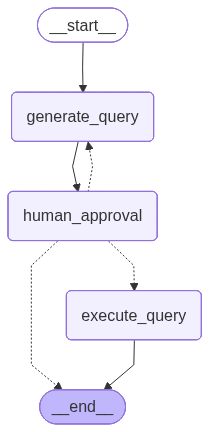

In [ ]:
# Visualize the graph (optional)
try:
    from IPython.display import Image, display
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Visualization not available: {e}")

---

## Run Your Implementation

Test the approval/rejection workflow with a sample query request.

In [ ]:
# Test 1: Start the workflow
print("TEST 1: Starting workflow")
print("=" * 60)

config = {"configurable": {"thread_id": "query-session-1"}}

initial_state = {
    "request": "Show me all customers who signed up in November 2024",
    "proposed_query": "",
    "rejection_feedback": "",
    "retry_count": 0,
    "status": "generating",
    "results": ""
}

result = app.invoke(initial_state, config)

print("\n" + "=" * 60)
print("Workflow paused for human approval!")
print(f"Status: {result['status']}")

TEST 1: Starting workflow

Generating SQL query (attempt 1)...
Generated query:
```sql
SELECT * FROM customers WHERE signup_date >= '2024-11-01' AND signup_date < '2024-12-01';
```

HUMAN APPROVAL REQUIRED

Proposed SQL Query (attempt 1/3):
----------------------------------------
```sql
SELECT * FROM customers WHERE signup_date >= '2024-11-01' AND signup_date < '2024-12-01';
```
----------------------------------------

Workflow paused for human approval!
Status: pending_approval


In [ ]:
# Test 2: Reject the query with feedback
print("TEST 2: Rejecting query with feedback")
print("=" * 60)

# Resume with a rejection decision
result = app.invoke(
    Command(
        resume={
            "decisions": [
                {
                    "type": "reject",
                    "message": "Please also include the customer's plan_type in the results and order by signup_date descending"
                }
            ]
        }
    ),
    config
)

print("\n" + "=" * 60)
print(f"Status after rejection: {result['status']}")

TEST 2: Rejecting query with feedback

HUMAN APPROVAL REQUIRED

Proposed SQL Query (attempt 1/3):
----------------------------------------
```sql
SELECT * FROM customers WHERE signup_date >= '2024-11-01' AND signup_date < '2024-12-01';
```
----------------------------------------
Reached max retries:3

Generating SQL query (attempt 2)...
Generated query:
```sql
SELECT id, name, email, signup_date, plan_type 
FROM customers 
WHERE signup_date >= '2024-11-01' AND signup_date < '2024-12-01' 
ORDER BY signup_date DESC;
```

HUMAN APPROVAL REQUIRED

Proposed SQL Query (attempt 2/3):
----------------------------------------
```sql
SELECT id, name, email, signup_date, plan_type 
FROM customers 
WHERE signup_date >= '2024-11-01' AND signup_date < '2024-12-01' 
ORDER BY signup_date DESC;
```
----------------------------------------

Status after rejection: pending_approval


In [ ]:
# Test 3: Approve the regenerated query
print("TEST 3: Approving the query")
print("=" * 60)

# Resume with an approval decision
final_result = app.invoke(
    Command(
        resume={
            "decisions": [
                {
                    "type": "approve"
                }
            ]
        }
    ),
    config
)

print("\n" + "=" * 60)
print("WORKFLOW COMPLETE")
print("=" * 60)
print(f"Final Status: {final_result['status']}")

TEST 3: Approving the query

HUMAN APPROVAL REQUIRED

Proposed SQL Query (attempt 2/3):
----------------------------------------
```sql
SELECT id, name, email, signup_date, plan_type 
FROM customers 
WHERE signup_date >= '2024-11-01' AND signup_date < '2024-12-01' 
ORDER BY signup_date DESC;
```
----------------------------------------

EXECUTING APPROVED QUERY

Query: ```sql
SELECT id, name, email, signup_date, plan_type 
FROM customers 
WHERE signup_date >= '2024-11...
Query executed successfully!
    
Results (3 rows):
+----+----------------+-------------------------+-------------+
| id | name           | email                   | signup_date |
+----+----------------+-------------------------+-------------+
| 42 | Alice Johnson  | alice@example.com       | 2024-11-15  |
| 43 | Bob Smith      | bob.smith@example.com   | 2024-11-18  |
| 44 | Carol Williams | carol.w@example.com     | 2024-11-22  |
+----+----------------+-------------------------+-------------+

WORKFLOW COMPLETE
Final

---

## Expected Output

If your implementation is correct, you should see:

**Test 1 (Initial):**
- Query is generated
- Workflow pauses at `human_approval` node
- Status: `pending_approval`

**Test 2 (Rejection):**
- Rejection feedback is captured
- New query is generated incorporating the feedback
- Workflow pauses again for approval
- Status: `pending_approval`

**Test 3 (Approval):**
- Query is approved
- Query executes and returns results
- Status: `executed`

```
HUMAN APPROVAL REQUIRED
============================================================
Proposed SQL Query (attempt 1/3):
----------------------------------------
SELECT * FROM customers WHERE signup_date >= '2024-11-01' AND signup_date < '2024-12-01';
----------------------------------------

... (rejection) ...

Generating SQL query (attempt 2)...
Generated query:
SELECT id, name, email, signup_date, plan_type
FROM customers
WHERE signup_date >= '2024-11-01' AND signup_date < '2024-12-01'
ORDER BY signup_date DESC;

... (approval) ...

Query approved! Proceeding to execution.

EXECUTING APPROVED QUERY
============================================================
Query executed successfully!
```